<a href="https://colab.research.google.com/github/SajindraDasuniM/Predicting_oil_price_with_ARIMA_and_LSTM/blob/main/Assessment2_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import packages

In this notebook, I'm going to predict the oild price using ARIMA and LSTM models

In [ ]:
from numpy import array
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import math
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

from google.colab import files # to import files
from sklearn.model_selection import train_test_split # split data to train and test
from sklearn.preprocessing import RobustScaler # scale data

## Import dataset
OilPrice.csv dataset was uploaded to Google Colab and date column was converted to
datetime64. Date column was assigned to index. There were 421 rows and one
column: “price” which was type object. It was converted to numeric for analysis.

In [ ]:
uploaded = files.upload() # upload dataset to Google Colab

Saving OilPrice.csv to OilPrice.csv


In [ ]:
data = pd.read_csv("OilPrice.csv", parse_dates=["DATE"], # automatically convert column into datetime64 when importing
                   index_col="DATE")

In [ ]:
data.columns= ["price"]
data.head()

,price
DATE,
4/1/2021,50.37
5/1/2021,53.16
6/1/2021,53.8
7/1/2021,53.7
8/1/2021,55.51


In [ ]:

data.info()# there is one column which is type "Object" and 421 rows/dates

<class 'pandas.core.frame.DataFrame'>
Index: 421 entries, 4/1/2021 to 15/08/2022
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   price   421 non-null    object
dtypes: object(1)
memory usage: 6.6+ KB


In [ ]:
data['price'] = pd.to_numeric(data['price'], errors='coerce') # change price to numeric

## 2.2 (a) Plot oil price and its returns

In [ ]:
data['ln_price'] = np.log(data['price'])
data['ln_price_diff'] = data['ln_price'].diff(1)
data['returns'] = data['ln_price'] - data['ln_price_diff']

data.head()

,price,ln_price,ln_price_diff,returns
DATE,,,,
4/1/2021,50.37,3.919396,NaN,NaN
5/1/2021,53.16,3.973306,0.053910,3.919396
6/1/2021,53.80,3.985273,0.011967,3.973306
7/1/2021,53.70,3.983413,-0.001860,3.985273
8/1/2021,55.51,4.016563,0.033150,3.983413


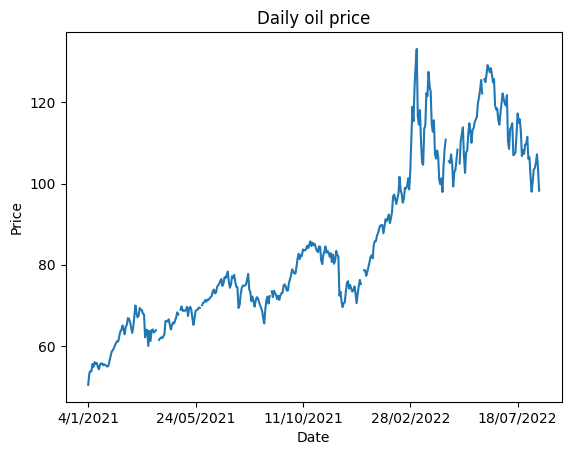

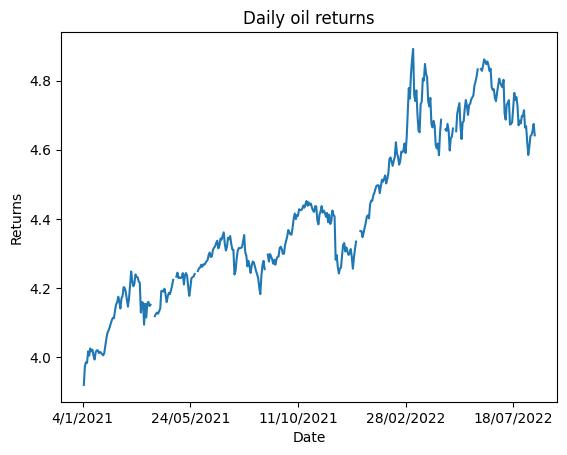

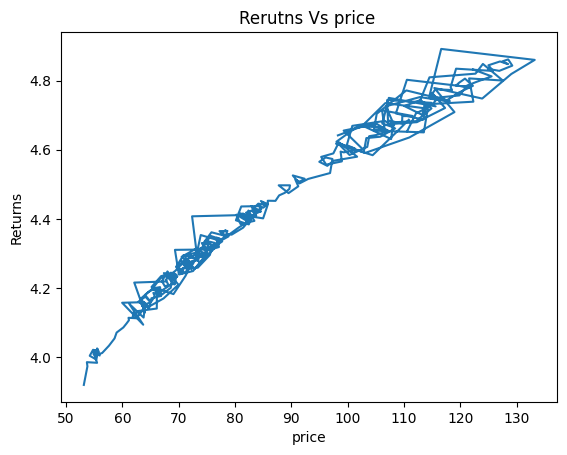

In [ ]:
plt.figure()
data['price'].plot(title="Daily oil price", xlabel="Date", ylabel="Price") # there is an incresing trend in the price over the time and the variance is also increasing with the time
plt.show()

data['returns'].plot(title="Daily oil returns", xlabel="Date", ylabel="Returns") # there is an incresing trend in the return  over the time. Both price and returns have the similar distribution shape
#because there is a linear relationship between the price and the returns as shown in the graph.
plt.show()

plt.plot(data["price"], data["returns"])
plt.title("Rerutns Vs price ")
plt.xlabel("price")
plt.ylabel("Returns")
plt.show()

The daily oil price and returns were plotted with time. Also, returns Vs price was plotted. There is an increasing trend in the price and returns over the time and the variance is also increasing with the time. Therefore, price and returns shows like non stationary time series as the values depend on time which will be confirmed later in the report. Both price and returns shows similar pattern because there is a linear relationship in the returns Vs time graph.

## 2.2 (b) Propose an approach to handle with missing values

In [ ]:
data.isna().sum() # there are 11 missing price values

,0
price,11
ln_price,11
ln_price_diff,20
returns,20


Since price and returns are continuous data, Linear Interpolation can be used to fill the missing values.

In [ ]:
data1 = data.interpolate(method='linear') # use linear interpolation method to fill missing data
data1.isna().sum() # Still Two missing values shown in ln_price_diff and returns columns because the first row cannot be interpolated. Therefore use Backward Fill to use next known value.

,0
price,0
ln_price,0
ln_price_diff,1
returns,1


In [ ]:
data2 = data1.bfill() # Backward Fill
data2.isna().sum()

,0
price,0
ln_price,0
ln_price_diff,0
returns,0


Weekend data was not available in the dataset which was ignored as this was not operating in
weekends. However, there were 11 entries in data where the price value was missing. Missing values in the timeseries models will result in bad performance as it violates the
assumption of continuous dates. Therefore, these were imputed using linear interpolation
method by considering the continuous nature. Still Two missing values were shown in
ln_price_diff and returns columns because the first row couldn’t be interpolated. Therefore again
Backward Fill was used to impute.  

# ARIMA model

## 2.2 (c) Propose an ARMA(p,q)/ ARIMA (p,d,q) model

Augment Dickey fuller test
Apply ADF test to price, ln_price and ln_price_diff columns

In [ ]:
ad_fuller_price = adfuller(data2['price']) # check ADF for price column
print("ADF statistics =",ad_fuller_price[0])
print("p-value =",ad_fuller_price[1]) # p value is 0.4 which is greater than 0.05. Therefore, alternative hypothesis is rejected and the data is non-stationary as found from the plot.

ADF statistics = -1.7576610434054476
p-value = 0.40167501254472254


In [ ]:
ad_fuller_ln_price = adfuller(data2['ln_price']) # check ADF for price column
print("ADF statistics =",ad_fuller_ln_price[0])
print("p-value =",ad_fuller_ln_price[1]) # p value is 0.2 which is greater than 0.05. Therefore, alternative hypothesis is rejected and the data is still non-stationary.
# We can try to reduce the trend in ln_price by taking the difference with (t-1) data.


ADF statistics = -2.001224812711608
p-value = 0.28603631984342826


In [ ]:
ad_fuller_ln_price_diff = adfuller(data2['ln_price_diff']) # check ADF for price column
print("ADF statistics =",ad_fuller_ln_price_diff[0])
print("p-value =",ad_fuller_ln_price_diff[1]) # p value is less than 0.05. Therefore, we can reject the null hypothesis and the data is stationary. ln_price_diff can be used to
# predict using the ARIMA(p,d,q) model where d=1 because the time series becomes stationary after one lag.
print("Critical Values", ad_fuller_ln_price_diff[4])

ADF statistics = -10.274834616150317
p-value = 3.9152974440207014e-18
Critical Values {'1%': np.float64(-3.446205926287236), '5%': np.float64(-2.8685297226414734), '10%': np.float64(-2.570493298011322)}


One assumption in ARMA/ARIMA model is the data to be stationary. Augment Dickey fuller(ADF)
test was applied to price values to check the stationarity (Appendix 15). P value was 0.4 which is
greater than 0.05. Therefore, alternative hypothesis was rejected which means the data is non
stationary as shown from the plot.  
Next ln_price column was checked with ADF test. p value was 0.2 which was greater than 0.05.
Therefore, alternative hypothesis was rejected and the data was still non-stationary.  
Therefore, we can try to reduce the trend in ln_price by taking the difference with (t-1) data and
check whether the series is stationary. For ln_price_diff, P value was less than 0.05 and the ADF
statistics was less than the critical values. Therefore, the null hypothesis was rejected and the
data was considered stationary. This means ln_price can be used to predict using the
ARIMA(p,d,q) model where d=1 because the time series becomes stationary after one lag.

### Train test split

Assign to training set if date is before or equal to 29/07/2022. Consider the remaining as test set.

In [ ]:
train_set = data2[:"29/07/2022"]
test_set = data2[len(train_set):]
test_set

,price,ln_price,ln_price_diff,returns
DATE,,,,
1/8/2022,106.09,4.664288,-0.049826,4.714114
2/8/2022,106.51,4.668239,0.003951,4.664288
3/8/2022,101.82,4.623207,-0.045032,4.668239
4/8/2022,97.99,4.584865,-0.038341,4.623207
5/8/2022,100.31,4.608265,0.023400,4.584865
8/8/2022,103.46,4.639185,0.030920,4.608265
9/8/2022,103.81,4.642562,0.003377,4.639185
10/8/2022,105.06,4.654532,0.011969,4.642562
11/8/2022,107.19,4.674603,0.020071,4.654532


In [ ]:
 y_train = train_set["ln_price"]
 y_test = test_set["ln_price"]

## 2.2 (d) Fit the proposed ARMA/ARIMA to the training data

## Plot PACF(Partial auto correlation) and ACF for price

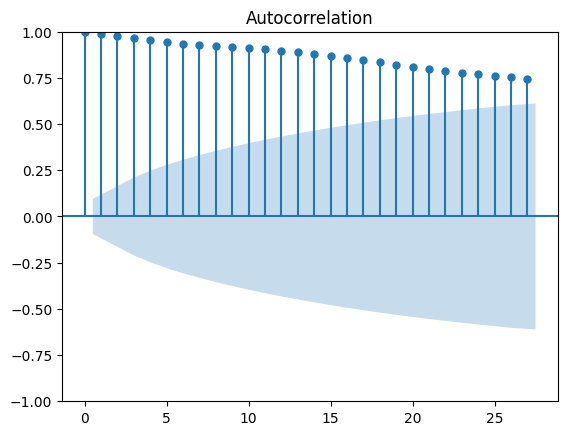

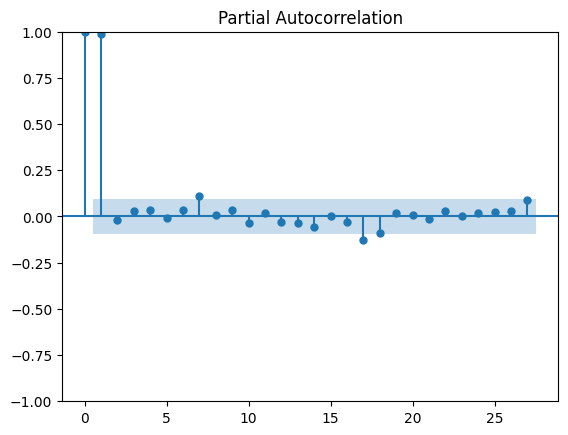

In [ ]:
plot_acf(data2['price'])
plot_pacf(data2['price'])
plt.show()

### Plot PACF(Partial auto correlation) and ACF for ln_price_diff

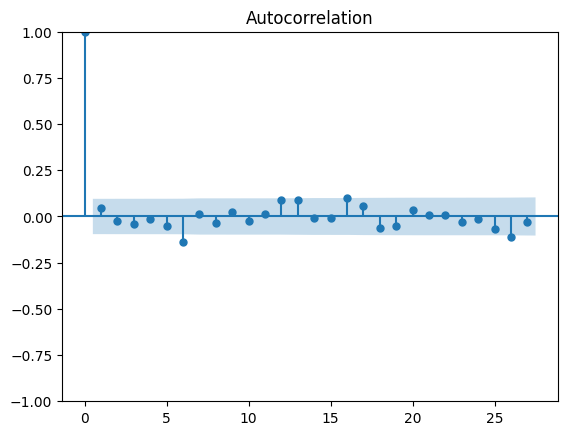

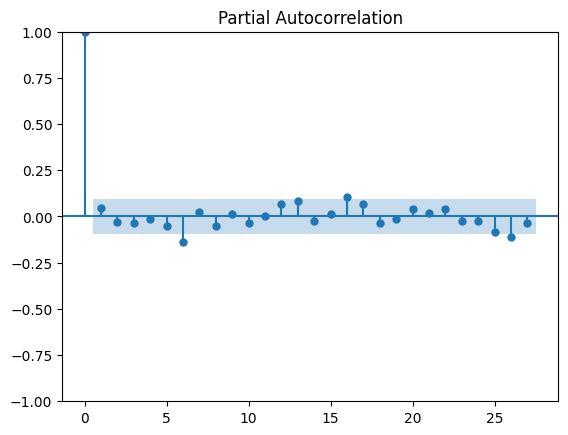

In [ ]:
plot_acf(data2['ln_price_diff'])
plot_pacf(data2['ln_price_diff'])
plt.show()

### Plot PACF(Partial auto correlation) and ACF for ln_price

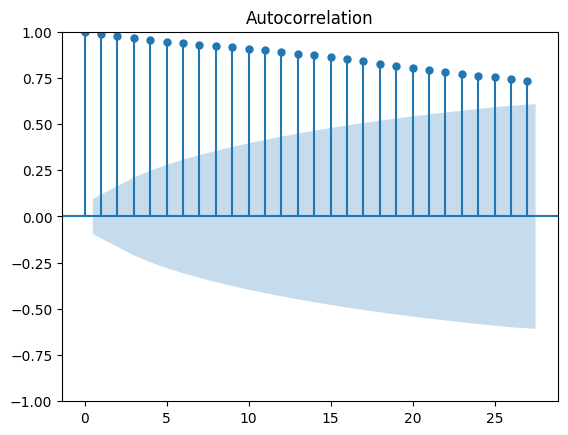

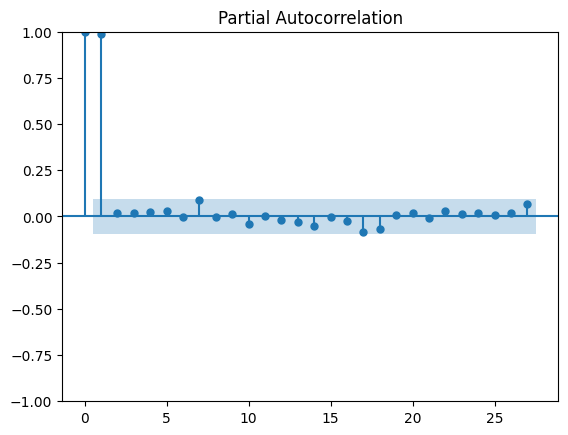

In [ ]:
plot_acf(data2['ln_price'])
plot_pacf(data2['ln_price'])
plt.show()

Price and ln_price has autocorrelation which has gradually decreasing trend which means the data is non stationry.  
When PACF(Partial auto correlation) and ACF plots for ln_price_diff were considered both plots cuts off sharply after lag 0. Therefore, we can roughly say p and q should be close to zero for ARIMA model.

### Fit the ARIMA **model**

Parameters:
p: how many past values matter

d: how many differences to make the series stationary

q: how many past errors the model uses to adjust its forecast

As mentioned earlier, d=1 and p and q should be close to zero.

Initially p, d and q were set to (1,1,1) and the performance was checked

In [ ]:
arima_model = ARIMA(y_train, order = (1,1,1)) # d=1 since ln_price_diff (one day difference) is used as shown on in ADF test
arima_model_fit = arima_model.fit()
print(arima_model_fit.summary()) # all coefficients are statistically significant (p<0.05)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               ln_price   No. Observations:                  410
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 918.820
Date:                Sun, 29 Jun 2025   AIC                          -1831.640
Time:                        10:11:11   BIC                          -1819.599
Sample:                             0   HQIC                         -1826.876
                                - 410                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8165      0.246      3.318      0.001       0.334       1.299
ma.L1         -0.8481      0.225     -3.765      0.000      -1.290      -0.407
sigma2         0.0007   2.84e-05     23.050      0.0

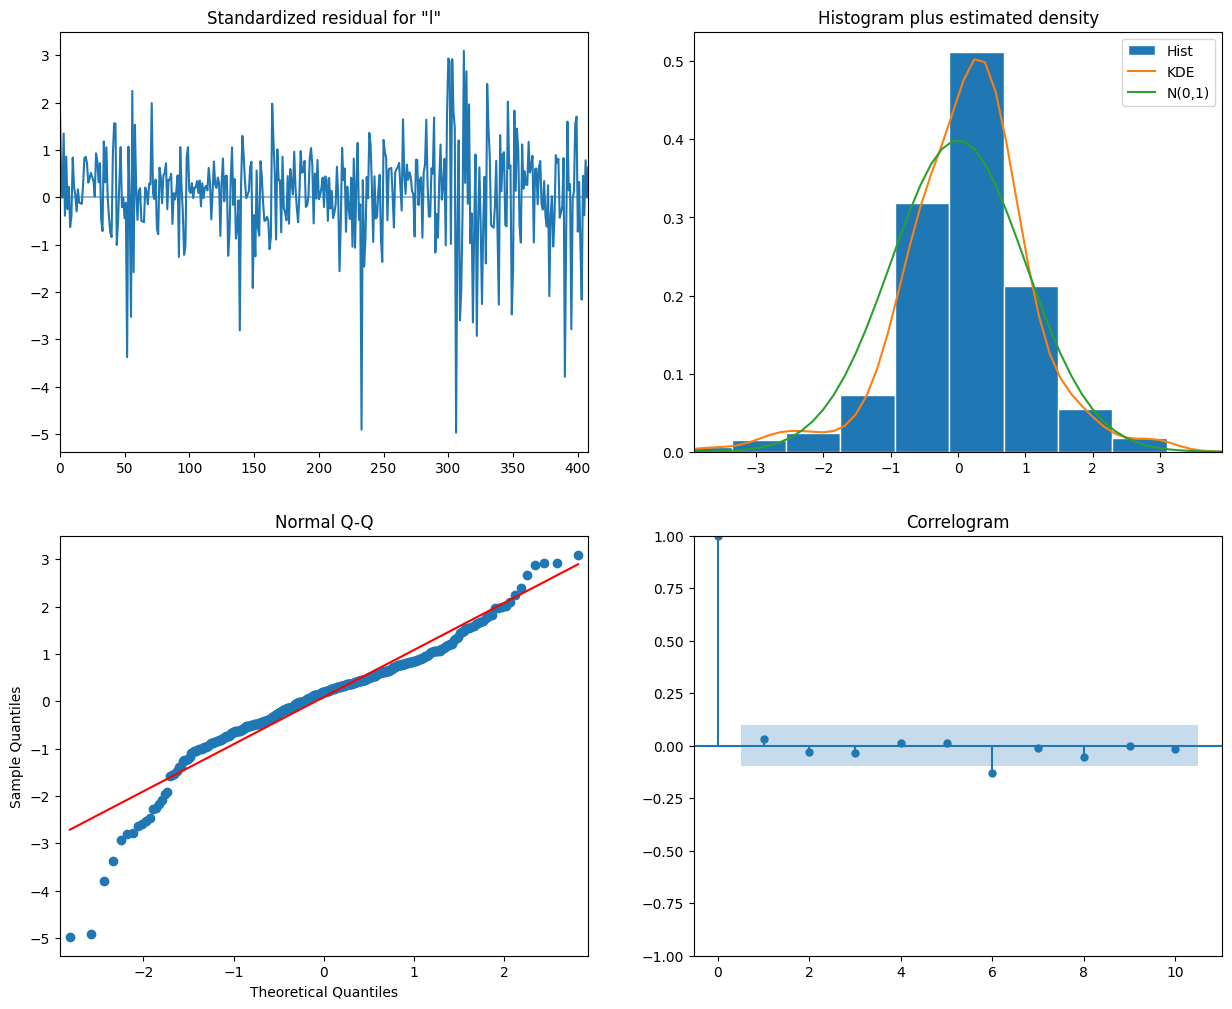

In [ ]:
arima_model_fit.plot_diagnostics(figsize=(15,12)); # visually assess the quality of your ARIMA model fit.

In [ ]:
predict = arima_model_fit.get_prediction(start=len(y_train), end=len(y_train) + len(y_test)-1) # predict for the test data

predict_ci = predict.conf_int() # predict confidence interval

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


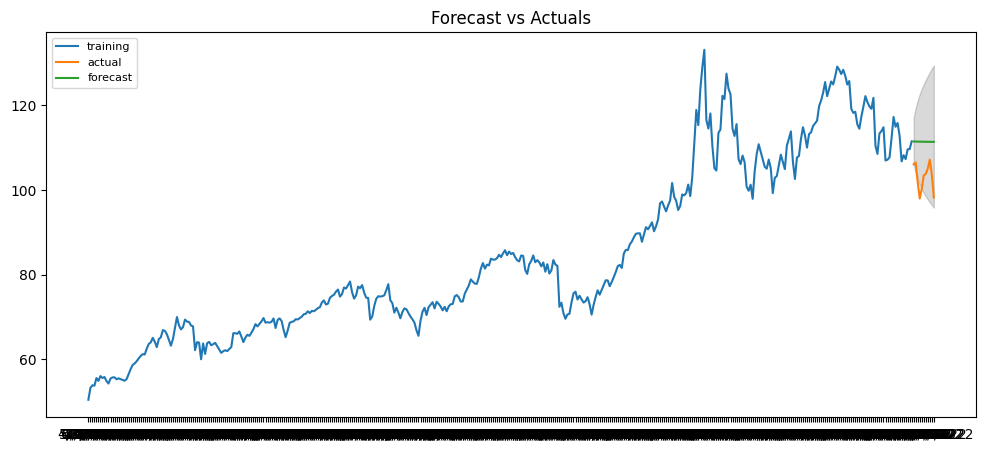

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(np.exp(y_train), label='training')
plt.plot(np.exp(y_test), label='actual')
plt.plot(np.exp(predict.predicted_mean), label='forecast')
plt.fill_between(predict_ci.index,
                 np.exp(predict_ci.iloc[:,0]),
                 np.exp(predict_ci.iloc[:,1]), color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

### Finetuning model

In [ ]:
p_values = [1,2,3,4,5]
q_values = range(0, 6)
for p in p_values:
     for q in q_values:
            order = (p,1,q)
            warnings.filterwarnings("ignore")
            model = ARIMA(y_train, order=order).fit()
            predictions = model.predict(start=len(y_train), end=len(y_train) + len(y_test)-1)
            error = math.sqrt(mean_squared_error(np.exp(y_test), np.exp(predictions)))
            AIC = model.aic
            BIC = model.bic
            print('ARIMA%s RMSE=%.4f' % (order,error), AIC, BIC)
            #print(order, error, AIC, BIC)

ARIMA(1, 1, 0) RMSE=8.9503 -1832.430384427394 -1824.4029541153084
ARIMA(1, 1, 1) RMSE=8.8540 -1831.6402069277115 -1819.599061459583
ARIMA(1, 1, 2) RMSE=8.7257 -1830.1074724550356 -1814.0526118308644
ARIMA(1, 1, 3) RMSE=8.6344 -1828.5067512761489 -1808.438175495935
ARIMA(1, 1, 4) RMSE=8.6217 -1826.5301999037151 -1802.4479089674583
ARIMA(1, 1, 5) RMSE=8.6042 -1824.556238623521 -1796.4602325312214
ARIMA(2, 1, 0) RMSE=8.8731 -1831.2713811375497 -1819.2302356694213
ARIMA(2, 1, 1) RMSE=8.9339 -1828.4897357833693 -1812.434875159198
ARIMA(2, 1, 2) RMSE=8.8799 -1827.4922588923982 -1807.4236831121843
ARIMA(2, 1, 3) RMSE=8.6287 -1826.7844384856596 -1802.7021475494028
ARIMA(2, 1, 4) RMSE=8.7288 -1825.241032659822 -1797.1450265675223
ARIMA(2, 1, 5) RMSE=8.6114 -1825.3748009622811 -1793.2650797139388
ARIMA(3, 1, 0) RMSE=8.7057 -1830.1569716640734 -1814.1021110399022
ARIMA(3, 1, 1) RMSE=8.7059 -1828.157371399647 -1808.088795619433
ARIMA(3, 1, 2) RMSE=8.8305 -1827.2258998901357 -1803.1436089538788
ARI

MSE measures the forecast performance/accuracy. AIC balances model fit and complexity and BIC prefer generalization. Lower MSE, AIC and BIC are better.  

All parameters were statistically significant (p value less than 0.05).  
Model was fine tuned using several p values (1 to 5) and q values (0 to 6). Even after fine tuning
the model with different combinations of p and q values, there is no significant difference in the
RMSE on test data which was around 9. RMSE measures the forecast performance/accuracy.  Also,
there was no considerable difference in AIC or BIC on training data which was around
1800. AIC balances model fit and complexity and BIC prefer generalization. Lower
MSE, AIC and BIC are better.  
However, only the (1,1,1) and (0,1,0) combinations were statistically significant. This means the
price variation over the time has a slightly similar behavior as a random walk of order (0,1,0) as
in most of the financial prices which makes predicting the price more difficult.

Then the fitted model was used to predict the oil price with the test data and plotted. Confidence interval was also predicted.

However, this ARIMA model(1,1,1) could not accurately forecast the nonlinear pattern in original
price data as shown in the actual Vs prediction plot. This is because ARIMA is a linear model and
therefore, it cannot accurately predict nonlinear patterns.

## 2.2 (e) LSTM model

LSTM model can be used to forecast nonlinear timeseries patterns more accurately when
compared to ARIMA models. Because LSTM has memory cells and it can capture nonlinear
patterns and long term dependencies.  
Proposed LSTM model has two LSTM layers with 16 and 20 neurons. By default Sigmoid function
was used for input, forget, and output gates and Tanh activation for the cell state update. Adam
optimizer was used with early stopping as regularization to minimize overfitting. Mean squared
error was used as loss parameter.

In [ ]:
data_lstm = data2.drop(data2.columns[[1,2,3]], axis=1) # drop ln_price, ln_price_diff and returns columns for LSTM
train_lstm = train_set.drop(train_set.columns[[1, 2, 3]], axis=1) # # drop ln_price, ln_price_diff anf returns columns for LSTM
train_size =len(train_lstm)
#print(train_size)
print(data_lstm.shape)
print(train_lstm.shape)


(421, 1)
(410, 1)


In [ ]:
# normalize the dataset
scaler = RobustScaler()
scaler_fit = scaler.fit(train_lstm[["price"]]) # fit the scalter to training set
data_lstm_scaled = scaler_fit.transform(data_lstm[["price"]])
data_lstm_scaled = pd.DataFrame(data_lstm_scaled, index=data_lstm.index, columns=['price'])

create the dataset to feed in LSTM

In [ ]:
def create_dataset(X,y,time_steps):
    Xs, ys = [],[]
    for i in range(len(X)-time_steps):
        v = X.iloc[i:(i+time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i+time_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
time_steps = 2
X_lstm_scaled, Y_lstm_scaled = create_dataset(data_lstm_scaled, data_lstm_scaled["price"], time_steps)

print(X_lstm_scaled.shape)
print(Y_lstm_scaled.shape)

(419, 2, 1)
(419,)


In [ ]:
X_lstm_scaled_train, X_lstm_scaled_test = X_lstm_scaled[0:train_size-time_steps,:,:], X_lstm_scaled[train_size-time_steps:,:,:]
Y_lstm_scaled_train, Y_lstm_scaled_test = Y_lstm_scaled[0:train_size-time_steps], Y_lstm_scaled[train_size-time_steps:]

print(X_lstm_scaled_train.shape, Y_lstm_scaled_train.shape)
print(X_lstm_scaled_test.shape, Y_lstm_scaled_test.shape)

(408, 2, 1) (408,)
(11, 2, 1) (11,)


### Building a LSTM model

In [ ]:
np.random.seed(2)
tf.random.set_seed(2)
model_lstm = keras.models.Sequential([
    keras.layers.LSTM(16, activation='tanh',recurrent_activation='sigmoid', return_sequences=True),
    keras.layers.LSTM(20, activation='tanh',recurrent_activation='sigmoid'),
    keras.layers.Dense(1)
])

# compiler
model_lstm.compile(loss='mean_squared_error', optimizer='adam')

history_lstm = model_lstm.fit(X_lstm_scaled_train, Y_lstm_scaled_train, epochs=100, validation_split=0.1, callbacks=keras.callbacks.EarlyStopping(patience=10),shuffle=False)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.1719 - val_loss: 1.3255
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1547 - val_loss: 1.2245
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1497 - val_loss: 1.1058
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1444 - val_loss: 0.9694
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1380 - val_loss: 0.8142
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1302 - val_loss: 0.6421
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1207 - val_loss: 0.4612
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1095 - val_loss: 0.2881
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0969 - val_loss: 0.1461
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0829 - val_loss: 0.0562
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0676 - val_loss: 0.0195
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

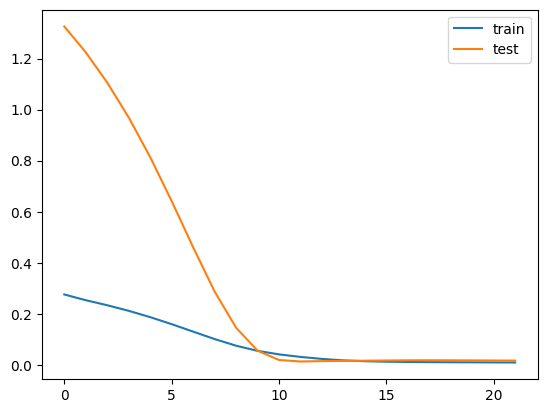

In [ ]:
plt.plot(history_lstm.history['loss'], label='train')
plt.plot(history_lstm.history['val_loss'], label='test')
plt.legend();

### Prediction

In [ ]:
# making prediction
Y_lstm_pred = model_lstm.predict(X_lstm_scaled_test)

# inverting predictions

Y_lstm_train_inv = scaler.inverse_transform(Y_lstm_scaled_train.reshape(1, -1)) #transforming y_train to column vector
Y_lstm_test_inv = scaler.inverse_transform(Y_lstm_scaled_test.reshape(1, -1))
Y_lstm_pred_inv = scaler.inverse_transform(Y_lstm_pred.reshape(1,-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


### Plot the prediction

In [ ]:
#X_lstm_scaled_train.shape
Y_lstm_scaled_train.shape

(408,)

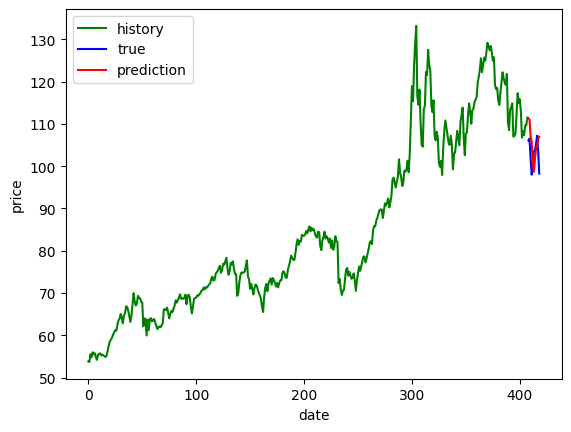

In [ ]:
# plotting

plt.plot(np.arange(0, len(Y_lstm_scaled_train)), Y_lstm_train_inv.flatten(), 'g', label="history")
plt.plot(np.arange(len(Y_lstm_scaled_train), len(Y_lstm_scaled_train) + len(Y_lstm_scaled_test)), Y_lstm_test_inv.flatten(), 'b', label="true")
plt.plot(np.arange(len(Y_lstm_scaled_train), len(Y_lstm_scaled_train) + len(Y_lstm_scaled_test)), Y_lstm_pred_inv.flatten(), 'r', label="prediction")
plt.ylabel('price')
plt.xlabel('date')
plt.legend()
plt.show();


Then the price was predicted for the test data (Appendix 25) and actual Vs prediction were plotted
After converting to original values using inverse_transform function(because the
data was scaled). As per Fig 10, model was able to predict the pattern accurately which is far
better than the ARIMA prediction.  

Calculating Root Mean squared errors

In [ ]:
RMSE_lstm = math.sqrt(mean_squared_error(Y_lstm_test_inv, Y_lstm_pred_inv))
print('Score: %.2f RMSE' % (RMSE_lstm))

Score: 4.83 RMSE


When
time_step = 1 --> RMSE = 3.78

time_step = 2 --> RMSE = 4.83

time_step = 3 --> RMSE = 5.65

time_step = 5 --> RMSE = 6.52

time_step = 7 --> RMSE ~ 7.01

When time_step = 1, prediction accuracy is very high and the forecast almost fit the actual test data in the plot. But then the model is using only one time differece of past values which reduce the potential of LSTM model to predict using long sequence data and learn the patterns. By considering this an optimum time_step can be used as 2.    

### conclusion
When both ARIMA and LSTM models were considered, LSTM shows high accuracy in predicting
the selected test data and it can accurately predict the test data pattern. ARIMA model was not
able to predict the test data pattern accurately. RMSE were around 5 and 9 for ARIMA and LSTM
models respectively. Therefore, LSTM model performs better. ARIMA model performance can be
further improved by considering seasonal impact (SARIMA).  
However, in both models, it is difficult to exactly predict the correct price only using historical
price values as there can be external factors such as economical and political etc. which have an  
impact on prices. Therefore, these factors also be considered when modeling to get more
realistic prediction.   